# Happy vs. Sad Face Classification Using CNN

In [42]:
import tensorflow as tf
import os
import cv2
import imghdr
import matplotlib.pyplot as plt
import numpy as np

In [43]:
# Make a variable for the data folder
data_dir='data'

# find what all folders are there inside data folder
os.listdir(data_dir)

# find what all files are there in happy folder
os.listdir(os.path.join(data_dir,'happy'))

# Image extenstion as list
image_ext=['jpg','jpeg','bmp','png']

In [44]:
# Remove files that are not in proper extention
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path=os.path.join(data_dir,image_class,image)
        try:
            img=cv2.imread(image_path)
            ext=imghdr.what(image_path)
            if ext not in image_ext:
                print(f"Image {image_path} does not have valid extension ")
                os.remove(image_path)
        except:
            print(f"Issue with the image {image_path} ")

In [45]:
# Load images, assign labels, shuffle them, and create batches
data = tf.keras.utils.image_dataset_from_directory('data')

# Scale the data
data=data.map(lambda x,y:(x/255,y))

# Create an iterator to access batches as NumPy arrays
data_iterator = data.as_numpy_iterator()

# Fetch the next batch
batch = data_iterator.next()

# Get the labels for all images in the batch
batch[1]

# Get all images in the batch as a NumPy array
batch[0]

# Get the shape of the images in one batch
batch[0].shape

Found 305 files belonging to 2 classes.


(32, 256, 256, 3)

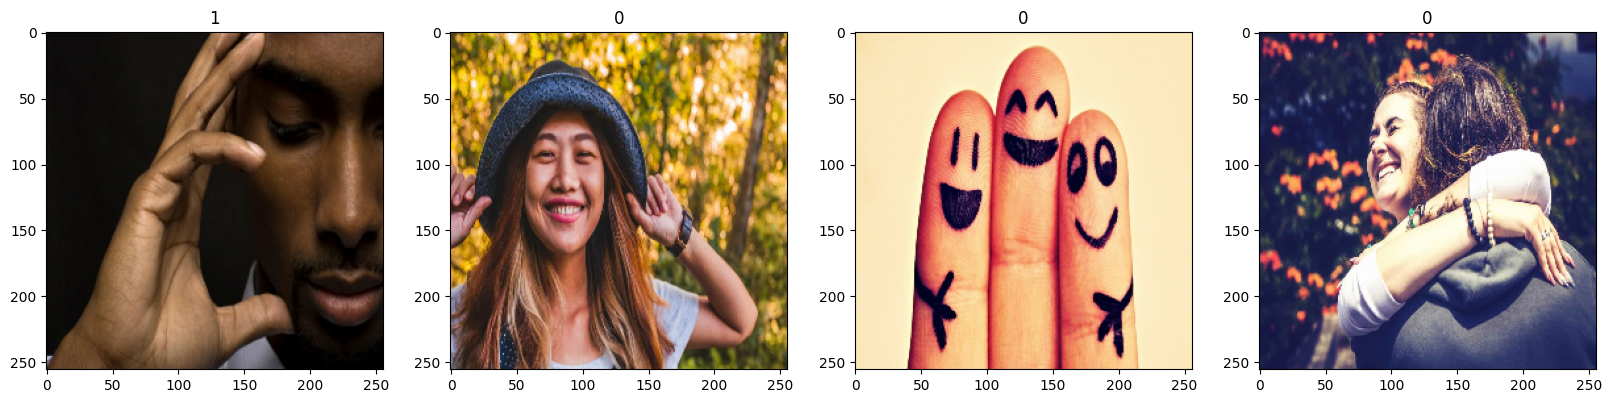

In [47]:
# Plot 4 images and find what label for each class
fig,ax=plt.subplots(ncols=4,figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

# 1 - sad 
# 0 - happy

In [56]:
# total number of batches
print(f"Total number of batches in dataset: {len(data)} ")

#Find the train,test and validation batch size
train_size = int(total_batches * 0.7)
val_size = int(total_batches * 0.2)
test_size = total_batches - train_size - val_size
print(f"Train size: {train_size}\nValidation size: {val_size}\nTest size: {test_size} ")

# split into test,train and validation 
rain = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)


Total number of batches in dataset: 10 
Train size: 7
Validation size: 2
Test size: 1 


10